### 영상처리를 위한 딥러닝 - 2

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## fashion_mnist 


holdout
- stratification
- 분할 비율 

In [2]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()

In [3]:
np.unique(y_train, return_counts=True) # 층화(stratified) 분류 이미 되어있음 

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

데이터셋 특징 
- mnist와 동일하게 배경이 없도록 전처리함
- center-alignede되어 있고 이미지로 꽉차 있음
- 데이터의 위치를 중점으로 지정
    - feature extraction이 쉬워 연산량이 많은 CNN을 안 써도 어느 정도 성능이 확보됨 
> 오컴의 면도날 
 성능이 동일하면 모델은 간단할 수록 좋음   
 https://ko.wikipedia.org/wiki/%EC%98%A4%EC%BB%B4%EC%9D%98_%EB%A9%B4%EB%8F%84%EB%82%A0

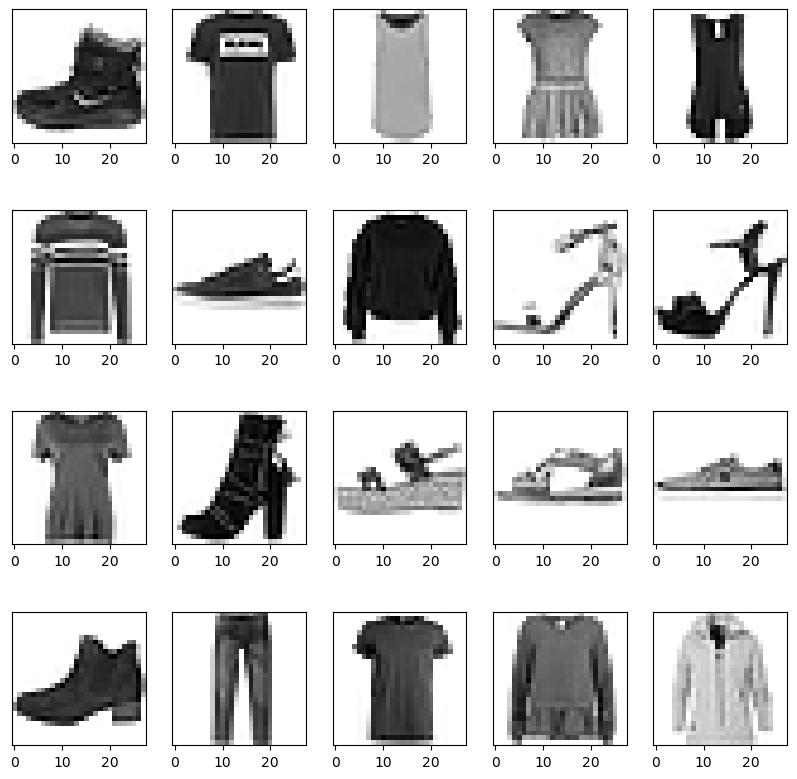

In [4]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(4,5,i+1) #  index로 이미지 
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
plt.show()

### activation
- 비선형 함수를 사용하여 원래 데이터를 마지막에 선형분류가 가능하도록 왜곡함
> Colah's blog post : https://colah.github.io/posts/2015-09-NN-Types-FP/
    - manifold learning(비선형 차원 축소)
- hidden layers의 activation function 필수
- sigmoid : 레이어가 많아지면서 미분값이 계속 0 에 가까워지면서 gradient vanishing 문제 생김
- relu (rectified) : 0보다 작으면 0, 크면 그값 그대로 
- softmax : 값을 0~1사이로 확률 값처럼 만들어줌

### activation 인자
- 문자열
    - 기본 default만 사용 가능 
        - 예 'relu'
-  함수
    - 소문자
    - tf의 keras.activations , nn package에 있음
    - functional paradigm 
    - 함수의 기본값 바꾸기 가능 
        - 예. tf.nn.relu
    - 함수는 first class function으로 객체로 쓰임
- functools partial로 가능 (decorator처럼 씀)하지만 복잡

In [5]:
tf.keras.activations.softmax

<function keras.src.activations.activations.softmax(x, axis=-1)>

In [6]:
tf.nn.softmax

<function tensorflow.python.ops.nn_ops.softmax_v2(logits, axis=None, name=None)>

In [7]:
tf.keras.activations.softmax is tf.nn.softmax

False

### layer
- layer많으면 데이터 많이 필요하고  layer가 많고 데이터가 적으면 overfitting 발생
- 앞의 layer 가 feature extraction
    - Dense 1차원 
    - Flatten 2차원 형태의 데이터를 받으면 1차원화
    - convolution은 3차원 형태의 데이터 받음

In [8]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(64, activation='relu') ,
    tf.keras.layers.Dense(64, activation=tf.nn.relu) ,
    tf.keras.layers.Dense(10, activation='softmax') # 마지막 결과 값을 확률값처럼 나오게 바꿈(optional)
])

/opt/anaconda3/envs/tf219_py311/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

### compile 
학습전략
#### loss
- 문제 도메인에 따라 정의된것을 사용
    - 실제값과 예측값을 어떻게 정의하는지에 따라 결정
-  문자열:
    -  오타 조심
    - 'sparse_categorical_crossentropy'
- 소문자: 함수
    - snake 방식
    - sparse_categorical_crossentropy
- 대문자 : 객체(Camel 방식)
    - 상속, 인자값 바꾸기 가능 
    - 인스턴스화
    - SparseCategoricalCrossentropy()
#### optimizer
- gradient vanishing을 어떤 알고리즘으로 효율적으로 해결할지를 선택
#### metrics
- 성능 비교 기준

In [10]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer='adam',metrics=['accuracy'])

In [11]:
dir(tf.keras.losses.SparseCategoricalCrossentropy())

['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_api_export_path',
 '_api_export_symbol_id',
 '_dtype',
 '_dtype_policy',
 '_fn_kwargs',
 '_obj_type',
 '_unpickle_model',
 'call',
 'dtype',
 'fn',
 'from_config',
 'from_logits',
 'get_config',
 'ignore_class',
 'name',
 'reduction']

In [12]:
type(tf.keras.losses.SparseCategoricalCrossentropy) # 객체 

type

In [13]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy
             , optimizer='adam',metrics=['accuracy'])

In [14]:
model.compile(loss='sparse_categorical_crossentropy'
             , optimizer='adam',metrics=['accuracy'])

### 정규화 비교
- -1 ~ 1사이 ,  0 ~ 1 사이 loss차이 별로 없으나 정규화 안한 데이터와의 loss차이는 큼

In [15]:
X_train128 = X_train/128 - 1
X_test128 = X_test/128 - 1

X_train255 = X_train/255
X_test255 = X_test/255

In [16]:
model.fit(X_train,y_train,epochs=5) # 정규화 안한 경우

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 722us/step - accuracy: 0.7188 - loss: 1.6956
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step - accuracy: 0.7799 - loss: 0.6679
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 699us/step - accuracy: 0.7987 - loss: 0.6203
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.8136 - loss: 0.5720
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 694us/step - accuracy: 0.8225 - loss: 0.5361


In [17]:
model.fit(X_train128,y_train,epochs=5)  # -1 ~ 1 사이

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - accuracy: 0.8201 - loss: 0.4951
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 704us/step - accuracy: 0.8600 - loss: 0.3862
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.8696 - loss: 0.3543
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.8774 - loss: 0.3316
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - accuracy: 0.8835 - loss: 0.3142


In [18]:
model.fit(X_train255,y_train,epochs=5) # 0~1사이가 약간 더 좋으나 유의미하지 않음

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 724us/step - accuracy: 0.8839 - loss: 0.3195
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - accuracy: 0.8910 - loss: 0.2936
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.8970 - loss: 0.2804
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - accuracy: 0.9008 - loss: 0.2681
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step - accuracy: 0.9039 - loss: 0.2587


### tensorflow이용한 이미지 전처리
- 내부적으로 PIL로 구현 되어 있음 
    - load_img(이미지)
        - 이미지 불러오기 
       - repr 자체가 이미지로 나옴
    - save_img(path, 3차원 이미지)
        - directory 설정 안하면 현재 작업하는 디렉토리에 저장됨
        - 기본 3차원, jpg
    - array_to_img
        - array에서 PIL기반 이미지
    - img_to_array 
        - 이미지에서 Numpy기반 이미지

In [19]:
from tensorflow.keras.preprocessing.image import load_img,save_img,array_to_img,img_to_array

In [20]:
save_img('boot.jpg',X_train255[0].reshape(28,28,1)) # 확장자 적용됨

In [21]:
img = load_img('boot.jpg')  # PIl.open()과 동일
img

- repr 자체가 이미지로 나옴
- PIL 로 처리됨

In [22]:
type(img)  # # PIL기반 jpg 확장자 파일 

PIL.Image.Image

In [23]:
from PIL import Image
img2=Image.open('boot.jpg')  #동일함
print(type(img2))  # JpegImageFile
img2

<class 'PIL.JpegImagePlugin.JpegImageFile'>


In [24]:
img_to_array(img) # numpy array

array([[[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 5.,  5.,  5.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [13., 13., 13.],
        [ 3.,  3.,  3.]],

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 8.,  8.,  8.],
        [ 0.,  0.,  0.]],

       ...,

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 5.,  5.,  5.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[11., 11., 11.],
        [ 1.,  1.,  1.],
        [ 5.,  5.,  5.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 4.,  4.,  4.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]]

간단한 이미지 처리는 keras.preprocessing.image로 처리

epoch	time	train/box_loss	train/cls_loss	train/dfl_loss	metrics/precision(B)	metrics/recall(B)	metrics/mAP50(B)	metrics/mAP50-95(B)	val/box_loss	val/cls_loss	val/dfl_loss
100에포크
100	25438.1	0.23385	0.07644	0.00343	0.99682	0.9979	0.99499	0.96067	0.27451	0.08987	0.00361
180에포크
10	1531.16	0.25145	0.08269	0.00384	0.99622	0.99885	0.99499	0.96643	0.26472	0.08353	0.00355
220에포크
10	1537.4	0.24831	0.08121	0.00378	0.99732	0.99839	0.99499	0.97384	0.24213	0.079	0.00327
240에포크
10	1438.61	0.24588	0.08123	0.00374	0.995	0.99615	0.99483	0.97145	0.24521	0.079	0.0033
300에포크
10	1566.55	0.2437	0.08011	0.0037	0.99625	0.99775	0.995	0.96885	0.25857	0.08134	0.00342

In [25]:
print(np.array(img).shape)
np.array(img) # Numpy로 array변경한 것과 동일

(28, 28, 3)


array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 5,  5,  5],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [13, 13, 13],
        [ 3,  3,  3]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 8,  8,  8],
        [ 0,  0,  0]],

       ...,

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 5,  5,  5],
        [ 0,  0,  0],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [ 1,  1,  1],
        [ 5,  5,  5],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 4,  4,  4],
        [ 0,  0,  0],
        [ 0,  0,  0]]], dtype=uint8)

In [26]:
print(img_to_array(img2).shape)
img_to_array(img2) #numpy array

(28, 28, 1)


array([[[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [ 17.],
        [  0.],
        [  3.],
        [  7.],
        [  1.],
        [  0.],
        [  2.],
        [  7.],
        [  3.],
        [  0.],
        [  0.],
        [  5.],
        [  1.],
        [  0.],
        [  0.],
        [  0.],
        [  5.],
        [  0.],
        [  0.]],

       [[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  4.],
        [  0.],
        [  7.],
        [  0.],
        [  6.],
        [  1.],
        [  6.],
        [  0.],
        [  1.],
        [ 15.],
        [  0.],
        [  0.],
        [  0.],
        [ 10.],
        [  6.],
        [  0.],
        [  0.],
        [ 13.],
        [  3.]],

       [[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
    

In [27]:
print(np.array(img2).shape)
np.array(img2)

(28, 28)


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,  17,   0,   3,   7,
          1,   0,   2,   7,   3,   0,   0,   5,   1,   0,   0,   0,   5,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   7,   0,
          6,   1,   6,   0,   1,  15,   0,   0,   0,  10,   6,   0,   0,
         13,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   0,   7,   0,
          4,   0,   0,  22,   0,   0,  10,   5,   0,   0,   0,   1,   0,
          8,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   6,   0,   1,   3,   2,
          3,   0,  25,  71,   5,   0,   8,   0,   0,   7,   9,  11,   3,
          2,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   1,   0,   9,
          1,  39, 126, 130,  76,  40,  16,   0,   0,  12,   0,   0,   6,
          0,  10],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   9,   3,   0,   0,
          0,  98, 213, 161, 147, 140, 110,  42,   0,   0,   0,   6,  22,
         11,   3],
       [  

In [28]:
img.mode,img.format,img.size  # PIL metadata 

('RGB', None, (28, 28))

In [29]:
import inspect
print(inspect.getsource(save_img)) # PIL로 구현되어 있음

@keras_export(["keras.utils.save_img", "keras.preprocessing.image.save_img"])
def save_img(path, x, data_format=None, file_format=None, scale=True, **kwargs):
    """Saves an image stored as a NumPy array to a path or file object.

    Args:
        path: Path or file object.
        x: NumPy array.
        data_format: Image data format, either `"channels_first"` or
            `"channels_last"`.
        file_format: Optional file format override. If omitted, the format to
            use is determined from the filename extension. If a file object was
            used instead of a filename, this parameter should always be used.
        scale: Whether to rescale image values to be within `[0, 255]`.
        **kwargs: Additional keyword arguments passed to `PIL.Image.save()`.
    """
    data_format = backend.standardize_data_format(data_format)
    img = array_to_img(x, data_format=data_format, scale=scale)
    if img.mode == "RGBA" and (file_format == "jpg" or file_format == "jpeg"):


#### evaluate
 - 성능 비교
 - fit처럼 학습하는게 아닌 predict예측을 하여 epochs없음 
 - 각 모델 변경해서 비교


return 2개
- loss
- compile(metrics=[]) 에서 지정한 기준
    - accuracy

In [30]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - accuracy: 0.8510 - loss: 65.0268


[65.02679443359375, 0.8510000109672546]

In [31]:
model.predict(X_test)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step


array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [32]:
np.sum(model.predict(X_test)[1])  #softmax는 확률처럼 계산하여 합치면 1

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step


np.float32(1.0)

In [33]:
np.argmax(model.predict(X_test)[1]) #가장 큰 index 2번째

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step


np.int64(2)

### one-hot encoding
- to_categorical
    - label encoding된 y를 one-hot encoding함
    - tf,pandas, scikit-learn
    - 구분자 역할을 하므로 label encodin과 성능 차이는 없음

In [34]:
from tensorflow.keras.utils import to_categorical

In [35]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()
y_train,y_train.shape

(array([9, 0, 0, ..., 3, 0, 5], dtype=uint8), (60000,))

In [36]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_train,y_train.shape

(array([[0., 0., 0., ..., 0., 0., 1.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 (60000, 10))

In [37]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(64, activation='relu') ,
    tf.keras.layers.Dense(64, activation=tf.nn.relu) ,
    tf.keras.layers.Dense(10, activation='softmax') # 마지막 결과 값을 확률값처럼 나오게 바꿈(optional)
])

model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer='adam',metrics=['accuracy'])

In [38]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 742us/step - accuracy: 0.7015 - loss: 1.9232
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 735us/step - accuracy: 0.7628 - loss: 0.6916
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 748us/step - accuracy: 0.7836 - loss: 0.6575
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step - accuracy: 0.7650 - loss: 0.6564
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step - accuracy: 0.7414 - loss: 0.6704


In [39]:
model.predict(X_test)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step


array([0.01729575, 0.00452836, 0.40767747, 0.01450982, 0.2924141 ,
       0.00249886, 0.24162523, 0.00066072, 0.01815223, 0.00063749],
      dtype=float32)

In [40]:
np.argmax(model.predict(X_test)[1]) # 동일하게 2번째 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 320us/step


np.int64(2)

In [41]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.7404 - loss: 0.7036


[0.7035773396492004, 0.7404000163078308]

In [42]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu') ,  # 64 ---> 128 
    tf.keras.layers.Dense(128, activation='relu') ,  # 64 ---> 128
    tf.keras.layers.Dense(10, activation='softmax') # 마지막 결과 값을 확률값처럼 나오게 바꿈(optional)
])

model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer='adam',metrics=['accuracy'])

In [43]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7396 - loss: 1.9389
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7868 - loss: 0.6517
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8038 - loss: 0.5932
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8218 - loss: 0.5283
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8337 - loss: 0.4829


In [44]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - accuracy: 0.8301 - loss: 0.5047


[0.5046929717063904, 0.8300999999046326]

딥러닝: 레이어가 많은 multi-layer perceptron
- 중요도 : layer > node
- layer지나갈때마다 데이터 공간을 왜곡시키기 때문에 layer가 더 중요함

In [45]:
model.predict(X_test)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step


array([9.05038687e-05, 1.52320104e-06, 9.93193746e-01, 2.33898973e-05,
       2.63926899e-03, 1.00492635e-07, 4.01756400e-03, 2.50557325e-10,
       3.01258224e-05, 3.59152659e-06], dtype=float32)

In [46]:
np.argmax(model.predict(X_test)[1]) # 동일하게 2번째 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step


np.int64(2)

### 하이퍼파라미터 튜닝
- 모델 선택후 모델의 하이퍼파라미터를 비교 선택해야하는데 수동으로 하면 오래걸리므로 자동화 하는 방법이 있다
    - scikit 의 gridsearchCV
    - Keras의 Keras Tuner
        - 후자는 나중에, https://www.tensorflow.org/tutorials/keras/keras_tuner?hl=ko

#### gridsearchCV
- 자동화된 하이퍼 파라미터 찾아서 최적화
- scikit-learn, keras 연동 가능 
    - keras GPU 지원하기 때문에 연동하면 scikit가능
    - KerasClassifier,  KerasRegressor 객체 인스턴스화 하여 사용 
####  KerasClassifier
- instance화
- = KerasClassifier( build_fn)
- classification 모델을 함수를 인자로 받음 

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

ModuleNotFoundError: No module named 'tensorflow.keras.wrappers.scikit_learn'

In [ ]:
def build_model( ): 
    
    model=tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu') ,
        tf.keras.layers.Dense(10, activation='softmax') 
    ])
    model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer='adam' ,metrics=['accuracy'])
    
    return model

In [ ]:
def build_model(optimizer='adam' ): 
    
    model=tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu') ,
        tf.keras.layers.Dense(10, activation='softmax') 
    ])
    model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer= optimizer ,metrics=['accuracy'])
    
    return model

In [ ]:
kc = KerasClassifier(build_fn=build_model) # 함수로 받음

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22416\2938288046.py:1: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  kc = KerasClassifier(build_fn=build_model) # 함수로 받음


In [ ]:
kc.fit(X_train,y_train,epochs=3)  # GPU 지원 됨

Epoch 1/3
1875/1875 [==============================] - 5s 3ms/step - loss: 3.0658 - accuracy: 0.6970
Epoch 2/3
1875/1875 [==============================] - 5s 2ms/step - loss: 0.6534 - accuracy: 0.7751
Epoch 3/3
1875/1875 [==============================] - 5s 2ms/step - loss: 0.6182 - accuracy: 0.7836


In [ ]:
tf.keras.backend.clear_session()

In [ ]:
# ! pip install scikeras
# from scikeras.wrappers import KerasClassifier, KerasRegressor
kc=KerasClassifier( build_fn=build_model) 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22416\3584946843.py:3: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  kc=KerasClassifier( build_fn=build_model)


In [ ]:
grid=GridSearchCV(kc, param_grid={'optimizer':['adam', 'rmsprop','adadelta']} )

In [ ]:
# GPU 지원됨
grid.fit(X_train,y_train,epochs=1)  # cross validaton까지 함 , 3개 파라메터 * 5번 split(cv) -> 15회 학습
                                    # cv=None to use the default 5-fold cross validation

1875/1875 [==============================] - 6s 3ms/step - loss: 3.1753 - accuracy: 0.6915


,estimator,<keras.wrappe...002488AFCABC0>
,param_grid,"{'optimizer': ['adam', 'rmsprop', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


cv_results_
- GridSearchCV 한 결과로  학습 속도, cross validation score 값보여줌

adam > rmsprop >adadelta 순서

In [ ]:
import pandas as pd
pd.DataFrame(grid.cv_results_)  # adam or rmsprop이 제일 빠르고 score도 가장 좋음

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_optimizer,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,4.374190,0.424259,1.078984,0.276262,adam,{'optimizer': 'adam'},0.719500,0.693333,0.734500,0.721833,0.686833,0.711200,0.018099,2
1,5.365456,0.217501,1.062134,0.055276,rmsprop,{'optimizer': 'rmsprop'},0.754833,0.701500,0.732083,0.702250,0.728083,0.723750,0.020058,1
2,4.728728,0.261301,1.129672,0.129177,adadelta,{'optimizer': 'adadelta'},0.221000,0.243667,0.196250,0.278000,0.262667,0.240317,0.029140,3


In [ ]:
grid.best_estimator_,  grid.best_index_, grid.best_params_, grid.best_score_
# 결과는 'adam' 혹은 'rmsprop'으로 나옴

(<keras.wrappers.scikit_learn.KerasClassifier at 0x2488b0f47f0>,
 1,
 {'optimizer': 'rmsprop'},
 0.7237499952316284)

In [ ]:
def build_model(node=64): 
    model=tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(node, activation='relu') ,
        tf.keras.layers.Dense(10, activation='softmax') 
    ])
    model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer='adam',metrics=['accuracy']) # 'adam' 혹은 'rmsprop'으로
    
    return model

### keras.wrappers.scikit_learn
- \*\*sk_params keras의 인자 입력 받을수 있어 scikit과 분리하여 사용 가능 
- composition :객체지향에서 감싸서 한 기법
    - fit대신에 KerasClassifier에 epochs=3, validation_split  지정

In [ ]:
# keras.wrappers
kc=KerasClassifier( build_fn=build_model, epochs=3, validation_split=0.2) #함수로 받음 
# scikit-learn  
grid=GridSearchCV(kc,param_grid={'node':[64,128,256,512]},cv=2)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22416\27152232.py:2: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  kc=KerasClassifier( build_fn=build_model, epochs=3, validation_split=0.2) #함수로 받음


In [ ]:
grid.fit(X_train,y_train)  # cross validaton까지 함 , cv =2

Epoch 1/3
750/750 [==============================] - 3s 3ms/step - loss: 5.0424 - accuracy: 0.5957 - val_loss: 1.1984 - val_accuracy: 0.5855
Epoch 2/3
750/750 [==============================] - 2s 3ms/step - loss: 1.0269 - accuracy: 0.6274 - val_loss: 0.9823 - val_accuracy: 0.6403
Epoch 3/3
938/938 [==============================] - 2s 3ms/step - loss: 0.8675 - accuracy: 0.6666
Epoch 1/3
750/750 [==============================] - 2s 3ms/step - loss: 7.5336 - accuracy: 0.6182 - val_loss: 1.3630 - val_accuracy: 0.6157
Epoch 2/3
750/750 [==============================] - 2s 3ms/step - loss: 1.1246 - accuracy: 0.6346 - val_loss: 1.0771 - val_accuracy: 0.6630
Epoch 3/3
938/938 [==============================] - 4s 4ms/step - loss: 0.9260 - accuracy: 0.6846
Epoch 1/3
750/750 [==============================] - 4s 4ms/step - loss: 7.2303 - accuracy: 0.6847 - val_loss: 1.1920 - val_accuracy: 0.6883
Epoch 2/3
750/750 [==============================] - 3s 4ms/step - loss: 0.8573 - accuracy: 0.719

,estimator,<keras.wrappe...0024BF28BA6B0>
,param_grid,"{'node': [64, 128, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [ ]:
pd.DataFrame(grid.cv_results_) # node 많을 수록 성능 좋음

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_node,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
0,7.402814,0.104409,3.197969,0.629347,64,{'node': 64},0.666567,0.684567,0.675567,0.009000,4
1,8.896868,0.444318,3.427518,0.171136,128,{'node': 128},0.780667,0.757367,0.769017,0.011650,3
2,8.933183,0.647195,3.095631,0.107600,256,{'node': 256},0.794300,0.801000,0.797650,0.003350,2
3,9.223816,0.004229,3.386469,0.349036,512,{'node': 512},0.788433,0.819700,0.804067,0.015633,1


In [ ]:
grid.best_estimator_,  grid.best_index_, grid.best_params_, grid.best_score_
# 결과는 : 512

(<keras.wrappers.scikit_learn.KerasClassifier at 0x2488b032d70>,
 3,
 {'node': 512},
 0.8040666580200195)